/var/folders/4g/_4b7gwg52572r3yvvt5619t80000gn/T/ipykernel_22873/3939821080.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


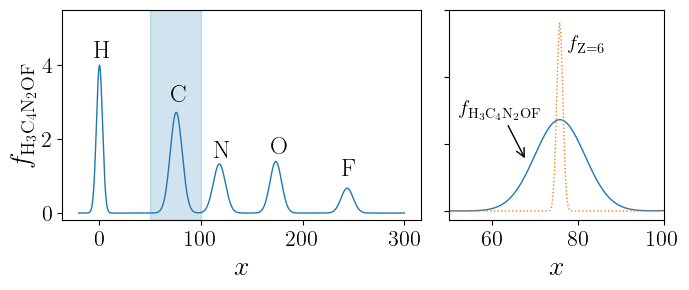

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from rdkit import Chem
from rdkit.Chem.Draw import MolToImage
import numpy as np
import seaborn as sns
import os
current_dir = os.getcwd() + "/"
sns_palette = sns.color_palette()
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # or "serif", "sans-serif", "monospace"
    'font.weight': 'bold',
    "font.serif": ["Times New Roman"] # Example for a specific font
    })
fontsize = 20
atom_nuclear_charge_dict = {
    "H":1,
    "C":6,
    "N":7,
    "O":8,
    "F":9
    }

atom_type = "C"
mol_size = 9
x_ls = np.linspace(-20, 300, 1000)#np.linspace(-100, 300, 400)
mu_power = 1.2
var_power = 0.7
di = 10
d_atom = 10
atom_var = 0.5

data_dir = f"{current_dir}FIG1/"
pdf = np.loadtxt(f"{data_dir}pdf.txt")
f_atom_i = np.loadtxt(f"{data_dir}f_atom_C.txt")


example_smi = "OC1=CN=C(F)N=C1"
mol = Chem.MolFromSmiles(example_smi)

fig, axs = plt.subplots(1,2,figsize=(7,3),
                        width_ratios = [2,1.2])
for i in range(2):
    axs[i].tick_params(labelsize = fontsize-4)

ax = axs[0]
ax.plot(x_ls, pdf, linewidth=1, c = sns_palette[0])
ax.set_xlabel(r"$x$", fontsize = fontsize)
# ax.set_ylabel(r"$\mathcal{N}_{H_{1}C_{4}N_{2}OF}}$", fontsize = fontsize)
ax.set_ylabel(r"$f_{\rm H_{3}C_{4}N_{2}OF}$", fontsize = fontsize)

y_ls = [4.2, 3., 1.5, 1.6, 1.]
idx = 0
for atom, Z in atom_nuclear_charge_dict.items():
    xi = (0.5*Z**2.4)**mu_power
    ax.text(xi-5, y_ls[idx],
            atom,
            fontsize= fontsize-2
    )
    idx+=1
ax.set_ylim(None,5.5)

ax.axvspan(50, 100, color=sns_palette[0], alpha=0.2)
    


from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG
mol_image = MolToImage(mol, size=(400, 200))
# drawer = rdMolDraw2D.MolDraw2DSVG(400, 200)
# drawer.DrawMolecule(mol) 
# drawer.FinishDrawing()
# mol_image = drawer.GetDrawingText().replace('svg:','')
inset_coord = [0.32, 0.6, 0.3, 0.3] # [left, bottom, width, height]
ax_inset = fig.add_axes(inset_coord)
# ax_inset.imshow(mol_image, zorder =0)
ax_inset.axis('off') 



ax = axs[1]
ax.plot(x_ls, pdf, linewidth=1, c = sns_palette[0])
ax.set_yticklabels([])

# calculated intersection f_atom

if atom_type == "H":
    atom_count_ls = np.arange(1,20,1)
else:
    atom_count_ls = np.arange(1,2,1)
ax.plot(x_ls, f_atom_i, ":", linewidth=1, c = sns_palette[1])

ax.annotate( 
        r"$f_{\rm H_{3}C_{4}N_{2}OF}$", 
        xy = (68, 1.5),
        xytext = (62, 3),
        fontsize=fontsize-5, 
        color = "k", ha='center', va='center',
        # arrow definition
        arrowprops=dict(facecolor=sns_palette[0], 
                            # shrink=0.05, 
                            arrowstyle="->", )
        )

ax.text( 82, 5,
        r"$f_{\rm Z = 6}$", 
        fontsize=fontsize-5, 
        color = "k", 
        ha='center', va='center',
        )

ax.set_xlabel(r"$x$", fontsize = fontsize)
ax.set_xlim(50,100)
ax.set_ylim(None, 6)
fig.tight_layout()

fig.savefig("figure1.pdf")

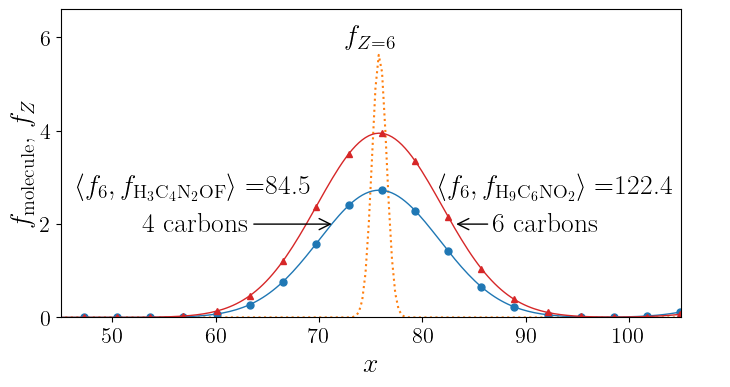

In [8]:
data_dir = f"{current_dir}FIG2/"
fig, ax = plt.subplots(1,1,figsize=(8,4))

ax.tick_params(labelsize = fontsize-4)

ax.set_xlim(45,105)
ax.set_ylim(None, 6.6)
ax.set_xlabel(r"$x$", fontsize = fontsize)
# ax.set_ylabel(r"$\mathcal{N}_{H_{1}C_{4}N_{2}OF}}$", fontsize = fontsize)
ax.set_ylabel(r"$f_{\rm molecule}$, $f_{Z}$", fontsize = fontsize)


# calculated intersection f_atom
ax.plot(x_ls, f_atom_i, ":", c = sns_palette[1],)

ax.text(75, 6,
        r"$f_{Z = 6}$", 
        fontsize=fontsize, 
        color = "k", 
        ha='center', va='center',
        )


smi_1 = "OC1=CN=C(F)N=C1"
c_1 = sns_palette[0]
mol1 = Chem.MolFromSmiles(smi_1)
pdf1 = np.loadtxt(f"{data_dir}pdf1.txt")

smi_2 = "O=C1CNC2COC1C2"
c_2 = sns_palette[3]
pdf2 = np.loadtxt(f"{data_dir}pdf2.txt")
mol2 = Chem.MolFromSmiles(smi_2)


ax.plot(x_ls, pdf1, c = c_1, marker = "o", markevery = 10, markersize = 5, linewidth=1)
inner_prod1 = round(np.inner(f_atom_i, pdf1),1)
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG
mol_image = MolToImage(mol1, size=(400, 200))
inset_coord = [0.15, 0.55, 0.27, 0.3] # [left, bottom, width, height]
ax_inset = fig.add_axes(inset_coord)
ax_inset.axis('off') 
ax.annotate( 
        "4 carbons",
        xy = (71.5, 2),
        xytext = (58, 2),
        fontsize=fontsize, 
        color = "k", ha='center', va='center',
        # arrow definition
        arrowprops=dict(facecolor=sns_palette[0], 
                            # shrink=0.05, 
                            arrowstyle="->", 

                            )
        )
ax.text(58, 2.8,
        r"$\langle f_6, f_{\rm H_{3}C_{4}N_{2}OF}\rangle =$%s"%inner_prod1, 
        fontsize=fontsize, 
        color = "k", 
        ha='center', va='center',
        )

ax.plot(x_ls, pdf2, c = c_2, marker = "^", markevery = 10, markersize = 5, linewidth=1)
inner_prod2 = round(np.inner(f_atom_i, pdf2),1)
mol_image = MolToImage(mol2, size=(250, 200))
inset_coord = [0.65, 0.57, 0.3, 0.28] # [left, bottom, width, height]
ax_inset = fig.add_axes(inset_coord)
ax_inset.axis('off') 
ax.annotate( 
        "6 carbons", 
        xy = (83, 2),
        xytext = (92, 2),
        fontsize=fontsize, 
        color = "k", ha='center', va='center',
        # arrow definition
        arrowprops=dict(facecolor=sns_palette[0], 
                            # shrink=0.05, 
                            arrowstyle="->", 

                            )
        )
ax.text(93, 2.8,
        r"$\langle f_6, f_{\rm H_{9}C_{6}NO_{2}}\rangle =$%s"%inner_prod2, 
        fontsize=fontsize, 
        color = "k", 
        ha='center', va='center',
        )

fig.savefig("figure_2.pdf")

prop_bin:[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38]
[[None None None 0 10]]
values: [[np.float64(461.6), np.int64(56), np.int64(1697), 10, 10], [np.float64(1054.125), np.int64(91), np.int64(2954), 8, 10]]
bo_avg: 724.9444444444445
0.9
values: [[np.float64(740.5555555555555), np.int64(67), np.int64(2019), 9, 10]]
bo_avg: 740.5555555555555
0.9
values: [[np.float64(1009.75), np.int64(76), np.int64(1924), 8, 10]]
bo_avg: 1009.75
0.8
values: [[np.float64(363.4), np.int64(82), np.int64(876), 10, 10], [np.float64(239.2), np.int64(98), np.int64(900), 10, 10], [np.float64(254.0), np.int64(75), np.int64(795), 10, 10]]
bo_avg: 285.53333333333336
1.0
values: [[np.float64(946.8), np.int64(194), np.int64(2464), 10, 10]]
bo_avg: 946.8
1.0
values: [[np.float64(215.9), np.int64(62), np.int64(582), 10, 10], [np.float64(198.7), np.int64(67), np.int64(337), 10, 10], [np.float64(505.4), np.int64(84), np.int64(1117), 10, 10]]
bo_avg: 306.6666666666667
1.0
values: [[n

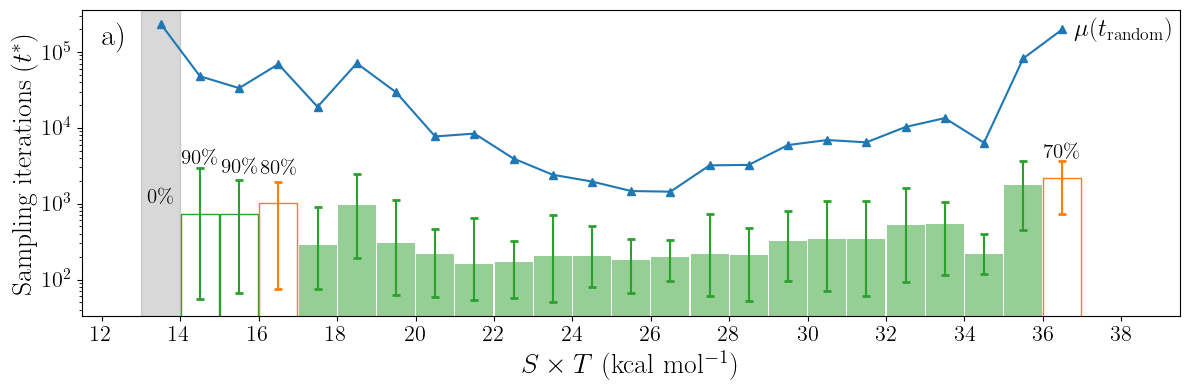

In [55]:

def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.

    Examples:
    >> lighten_color('g', 0.3)
    >> lighten_color('#F034A3', 0.6)
    >> lighten_color((.3,.55,.1), 0.5)
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

prop_label_dict = {"zpve":"ZPVE", 
                   "s": r"$S \times T$",
                   "h": "Enthalpy",
                   "u0": "Internal energy (0K)",
                   "u": "Internal energy (298K)",
                     "g": "Gibbs free energy",
                   }
prop_n = "s"
if prop_n == "zpve":
    # set the epislon_max value
    bin_size = 5
    bin_edges = np.arange(10, 170, bin_size)
    max_abs_err = 150
elif prop_n == "s":
    # set the epislon_max value
    max_abs_err = 40
    bin_size = 1
    bin_edges = np.arange(12, 39, bin_size)
    print (f"prop_bin:{bin_edges}")

fs = 20
ticks_fs = 16
import seaborn as sns

sns_palette = sns.color_palette()
fig, ax = plt.subplots(1, 1, 
                        figsize = (12, 4),
                        tight_layout = True)
fig5_s_dir = f"{current_dir}FIG5/{prop_n}/"
bar_plot_bo_dict = np.load(f"{fig5_s_dir}bar_plot_bo_dict.npy", allow_pickle=True)[()]  
for keys, values in bar_plot_bo_dict.items():
    val_arr = np.array(values)
    if len(val_arr) != 0:
        if None not in val_arr:
            print (f"values: {values}")
            bo_avg = np.sum([val_arr[i,0]*val_arr[i,3] for i in range(len(val_arr))])/np.sum([val_arr[i,3] for i in range(len(val_arr))])
            print ('bo_avg:', bo_avg)
            bo_mn = np.min([val_arr[i,1] for i in range(len(val_arr)) if val_arr[i,1] is not None])
            bo_mx = np.max([val_arr[i,2] for i in range(len(val_arr)) if val_arr[i,2] is not None])
            # print (bo_mn, bo_mx)
            success_rate = np.sum([val_arr[i,3] for i in range(len(val_arr))])/np.sum([val_arr[i,4] for i in range(len(val_arr))])
            print (success_rate)
            if success_rate == 1:
                marker_style = 'o'
                marker_color = sns_palette[2]  
                ax.bar(keys, bo_avg, 
                   width=bin_size*0.97,
                   color = lighten_color(marker_color, amount=1),
                   alpha = 0.5,
                   zorder = -1)
            else:
                marker_style = 's'
                if success_rate >= 0.9:
                    marker_color = sns_palette[2]
                else:
                    marker_color = sns_palette[1]
                ax.text(keys, bo_mx+1000, 
                    f"{round(success_rate*100)}\%", 
                    fontsize=15, 
                    color = "k", ha='center', va='center')
                ax.bar(keys, bo_avg, 
                   width=bin_size*0.97,
                   edgecolor = lighten_color(marker_color, amount=1),
                   facecolor = "none",
                #    alpha = 0.5,
                   zorder = -1)
            ax.errorbar(keys, bo_avg, 
                        yerr=np.array([bo_avg-bo_mn, bo_mx-bo_avg]).reshape(2,1), # yerr=plot_array[:,2],
                        # fmt=marker_style,
                        color = marker_color,
                        capsize=3, capthick=2, zorder = 0)
        else:
            print (val_arr)
            ax.axvspan(keys-bin_size*0.5, keys+bin_size*0.5, color='grey', alpha=0.3, zorder = -2)
            ax.text(keys, 1200, 
                    "0\%", 
                    fontsize=15, 
                    color = "k", ha='center', va='center')

# Plot random search results
rand_plt = np.loadtxt(f"{fig5_s_dir}rand_plt.txt")
ax.plot([x[0] for x in rand_plt], [x[1] for x in rand_plt], color=sns_palette[0], marker = "^", markersize=6)
ax.text(rand_plt[-1][0]+0.3*bin_size, rand_plt[-1][1], 
        r"$\mu(t_{\rm random})$", fontsize=fs-2, 
        # color=sns_palette[0], 
        ha='left', va='center')
y_min, y_max = ax.get_ylim()
# ax.set_ylim(0, y_max*1.2)
ax.set_xlim(bin_edges[0]-bin_size*0.5, bin_edges[-1]+bin_size*1.5)
ax.set_xlabel(r"%s (kcal mol$^{-1}$)"%(prop_label_dict[prop_n]), fontsize=fs)
ax.set_ylabel(r'Sampling iterations ($t^{*}$)', fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=ticks_fs)
ax.set_xticks(bin_edges[::2])
ax.set_xticklabels(bin_edges[::2])
ax.annotate("a)", xy = (12, y_max*0.5), fontsize=fs+2)
ax.set_yscale('log')

fig.savefig(f"figure5_a.pdf", bbox_inches='tight')

bar_plot_bo_dict: {np.float64(12.5): [], np.float64(13.5): [[None, None, None, 0, 10]], np.float64(14.5): [[np.float64(461.6), np.int64(56), np.int64(1697), 10, 10], [np.float64(1054.125), np.int64(91), np.int64(2954), 8, 10]], np.float64(15.5): [[np.float64(740.5555555555555), np.int64(67), np.int64(2019), 9, 10]], np.float64(16.5): [[np.float64(1009.75), np.int64(76), np.int64(1924), 8, 10]], np.float64(17.5): [[np.float64(363.4), np.int64(82), np.int64(876), 10, 10], [np.float64(239.2), np.int64(98), np.int64(900), 10, 10], [np.float64(254.0), np.int64(75), np.int64(795), 10, 10]], np.float64(18.5): [[np.float64(946.8), np.int64(194), np.int64(2464), 10, 10]], np.float64(19.5): [[np.float64(215.9), np.int64(62), np.int64(582), 10, 10], [np.float64(198.7), np.int64(67), np.int64(337), 10, 10], [np.float64(505.4), np.int64(84), np.int64(1117), 10, 10]], np.float64(20.5): [[np.float64(243.7), np.int64(82), np.int64(466), 10, 10], [np.float64(250.5), np.int64(138), np.int64(460), 10, 10

/var/folders/4g/_4b7gwg52572r3yvvt5619t80000gn/T/ipykernel_22873/2047162325.py:70: RuntimeWarning: invalid value encountered in scalar divide
  bo_avg = np.sum([val_arr[i,0]*val_arr[i,3] for i in range(len(val_arr)) if val_arr[i,0]!= None])/np.sum([val_arr[i,3] for i in range(len(val_arr)) if val_arr[i,3] != 0])


ValueError: zero-size array to reduction operation minimum which has no identity

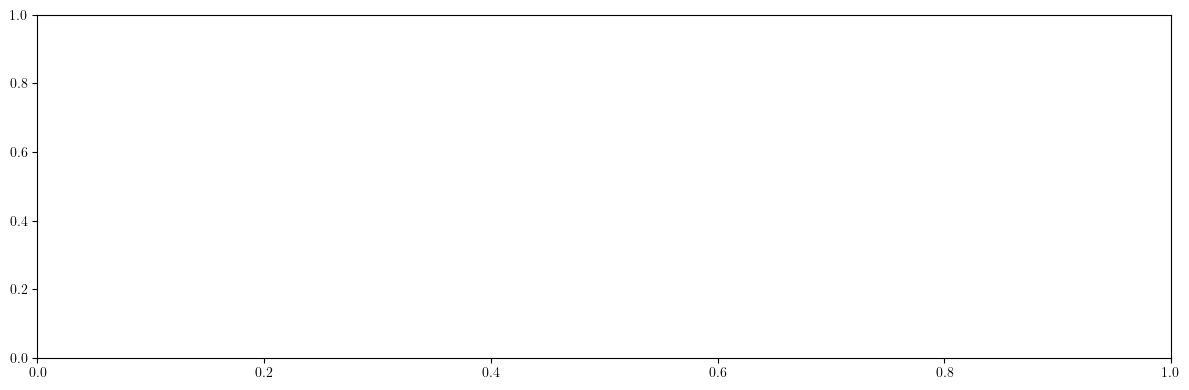

In [ ]:
if prop_n == "zpve":
    fs = 20
    ticks_fs = 16
elif prop_n == "s":
    fs = 20
    ticks_fs = 16
import seaborn as sns
sns_palette = sns.color_palette()
fig, ax = plt.subplots(1, 1, 
                        figsize = (12, 4),
                        tight_layout = True)
fig5_zpve_dir = f"{current_dir}FIG5/{prop_n}/"
bar_plot_bo_dict = np.load(f"{fig5_zpve_dir}bar_plot_bo_dict.npy", allow_pickle=True)[()]
print (f"bar_plot_bo_dict: {bar_plot_bo_dict}")

for keys, values in bar_plot_bo_dict.items():
    val_arr = np.array(values)
    if len(val_arr) != 0:
        if None not in val_arr:
            # print (f"values: {values}")
            bo_avg = np.sum([val_arr[i,0]*val_arr[i,3] for i in range(len(val_arr))])/np.sum([val_arr[i,3] for i in range(len(val_arr))])
            # print ('bo_avg:', bo_avg)
            bo_mn = np.min([val_arr[i,1] for i in range(len(val_arr)) if val_arr[i,1] is not None])
            bo_mx = np.max([val_arr[i,2] for i in range(len(val_arr)) if val_arr[i,2] is not None])
            # print (bo_mn, bo_mx)
            success_rate = np.sum([val_arr[i,3] for i in range(len(val_arr))])/np.sum([val_arr[i,4] for i in range(len(val_arr))])
            # print (success_rate)
            success_num = np.sum([val_arr[i,3] for i in range(len(val_arr))])
            total_tests = np.sum([val_arr[i,4] for i in range(len(val_arr))])
            if success_rate == 1:
                marker_style = 'o'
                marker_color = sns_palette[2]  
                ax.bar(keys, bo_avg, 
                   width=bin_size*0.97,
                   color = lighten_color(marker_color, amount=1),
                   alpha = 0.5,
                   zorder = -1)
            else:
                marker_style = 's'
                if success_rate >= 0.9:
                    marker_color = sns_palette[2]
                else:
                    marker_color = sns_palette[1]
                ax.text(keys, bo_mx+1000, 
                    # r"$\frac{%d}{%d}$"%(success_num, total_tests), 
                    f"{int(100*success_num/total_tests)}\%",
                    fontsize=12, 
                    color = "k", ha='center', va='center')
                # ax.text(keys, bo_mx+1000, 
                #     f"{round(success_rate*100)}\%", 
                #     fontsize=15, 
                #     color = "k", ha='center', va='center')
                ax.bar(keys, bo_avg, 
                   width=bin_size*0.97,
                   edgecolor = lighten_color(marker_color, amount=1),
                   facecolor = "none",
                #    alpha = 0.5,
                   zorder = -1)
            ax.errorbar(keys, bo_avg, 
                        yerr=np.array([bo_avg-bo_mn, bo_mx-bo_avg]).reshape(2,1), # yerr=plot_array[:,2],
                        # fmt=marker_style,
                        color = marker_color,
                        capsize=3, capthick=2, zorder = 0)
        else:
            marker_color = sns_palette[1]
            # print (val_arr)
            success_num = np.sum([val_arr[i,3] for i in range(len(val_arr))])
            total_tests = np.sum([val_arr[i,4] for i in range(len(val_arr))])
            print (f"val_arr[i,0]:{val_arr[:,0]}")
            print (f"val_arr[i,3]:{val_arr[:,3]}")
            bo_avg = np.sum([val_arr[i,0]*val_arr[i,3] for i in range(len(val_arr)) if val_arr[i,0]!= None])/np.sum([val_arr[i,3] for i in range(len(val_arr)) if val_arr[i,3] != 0])
            print ('bo_avg:', bo_avg)
            bo_mn = np.min([val_arr[i,1] for i in range(len(val_arr)) if val_arr[i,1] is not None])
            bo_mx = np.max([val_arr[i,2] for i in range(len(val_arr)) if val_arr[i,2] is not None])
            ax.bar(keys, bo_avg, 
                   width=bin_size*0.97,
                   edgecolor = lighten_color(marker_color, amount=1),
                   facecolor = "none",
                #    alpha = 0.5,
                   zorder = -1)
            ax.errorbar(keys, bo_avg, 
                        yerr=np.array([bo_avg-bo_mn, bo_mx-bo_avg]).reshape(2,1), # yerr=plot_array[:,2],
                        # fmt=marker_style,
                        color =  marker_color,
                        capsize=3, capthick=2, zorder = 0)
            ax.text(keys, bo_mx+1000, 
                    # r"$\frac{%d}{%d}$"%(success_num, total_tests), 
                    f"{int(100*success_num/total_tests)}\%",
                    fontsize=12, 
                    color = "k", ha='center', va='center')

# Plot random search results
rand_plt = np.loadtxt(f"{fig5_zpve_dir}rand_plt.txt")
ax.plot([x[0] for x in rand_plt], [x[1] for x in rand_plt], color=sns_palette[0], marker = "^", markersize=6)
ax.text(rand_plt[-1][0]+0.3*bin_size, rand_plt[-1][1], 
        r"$\mu(t_{\rm random})$", fontsize=fs-2, 
        # color=sns_palette[0], 
        ha='left', va='center')


# ax.fill_between([x[0] for x in rand_plt], [x[2] for x in rand_plt], [x[3] for x in rand_plt], color=sns_palette[0], alpha=0.3, zorder = -1)
y_min, y_max = ax.get_ylim()
# ax.set_ylim(0, y_max*1.2)
ax.set_xlim(bin_edges[0]-bin_size*0.5, bin_edges[-1]+bin_size*2)
ax.set_xlabel(r"%s (kcal mol$^{-1}$)"%(prop_label_dict[prop_n]), fontsize=fs)
ax.set_ylabel(r'Sampling iterations ($t^{*}$)', fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=ticks_fs)
ax.set_yscale('log')
ax.set_xticks(bin_edges[::2])
ax.set_xticklabels(bin_edges[::2])
ax.annotate("b)", xy = (10, y_max*0.5), fontsize=fs+2)


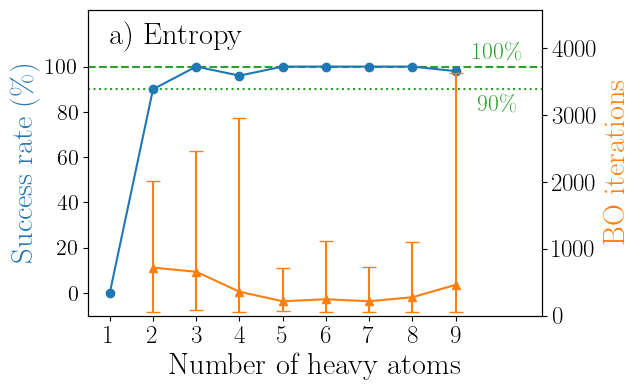

In [10]:
prop_n = "s"
ticks_fs = 18
fs = 22
fig, ax1 = plt.subplots(figsize=(6.5, 4), tight_layout = True)
ax1.tick_params(axis='both', which='major', labelsize=ticks_fs)

# Plot the second dataset on ax2
ax1_c = sns_palette[0]
fig6_dir = "%sFIG6/"%(current_dir)
success_rate_arr = np.loadtxt("%s%s_success_rate.txt"%(fig6_dir, prop_n))
ax1.plot(success_rate_arr[:,0], success_rate_arr[:,-1]*100, c = ax1_c, marker='o')
ax1.axhline(y = 100, color = sns_palette[2], linestyle = '--', zorder = 0)
ax1.axhline(y = 90, color = sns_palette[2], linestyle = ':', zorder = 0)

ax1.annotate('100\%', xy=(9.4, 103), color = sns_palette[2], fontsize=fs-5,
            #  bbox=dict(fc="white", ec="white"),
             )
ax1.annotate('90\%', xy=(9.5, 80), color = sns_palette[2], fontsize=fs-5,
            #  bbox=dict(fc="white", ec="white"),
             )
ax1.set_ylabel('Success rate (\%)', color=ax1_c, fontsize=fs)
ax1.set_xlabel('Number of heavy atoms', fontsize=fs)

ax1.tick_params(axis='y', labelsize=ticks_fs-2)
ax1.set_yticks(np.arange(0, 101, 20))
ax1.set_ylim(-10, 125)
ax1.set_xlim(0.5, 11)
ax1.set_xticks(np.arange(1,10,1))

ax1.annotate("a) Entropy", xy=(1, 110), fontsize=fs, )

# ax1.fill_between([1.8,9.2], 85, 105, color = ax1_c, alpha = 0.3)

# Create a twin axes sharing the x-axis
ax2 = ax1.twinx()
# Create the figure and the first axes
ax2_c = sns_palette[1]

bo_itr = np.loadtxt("%s%s_bo_iterations.txt"%(fig6_dir, prop_n))
n_atoms, bo_avg, bo_mn, bo_mx = bo_itr[:,0], bo_itr[:,1], bo_itr[:,2], bo_itr[:,3]

ax2.errorbar(n_atoms, bo_avg, yerr= [bo_avg-bo_mn, bo_mx-bo_avg], c = ax2_c, marker='^', capsize=5)

ax2.set_ylabel('BO iterations', color=ax2_c, fontsize=fs)
ax2.tick_params(axis='both',labelsize=ticks_fs)

ax2_ymin, ax2_ymax = ax2.get_ylim()
ax2.set_ylim(0, ax2_ymax*1.2)


# fig8_save_dir = create_dir("%sFIG8/"%(save_fig_dir))
# fig.savefig(fig8_save_dir+"/figure_%s.pdf"%(prop_n))
# fig.savefig(defence_plt_dir+"gpbo_entropy_bo_itr.pdf")
fig.savefig("figure_6_a.pdf")


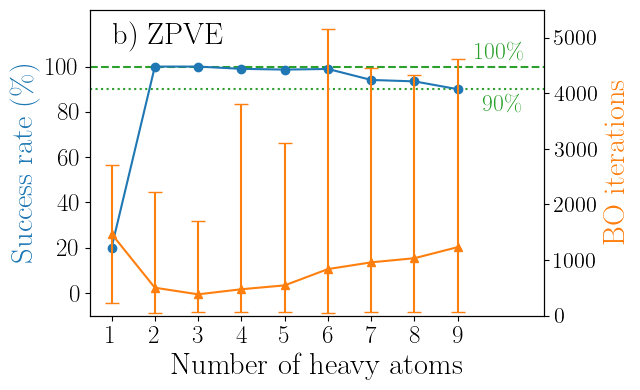

In [11]:
prop_n = "zpve"

fig, ax1 = plt.subplots(figsize=(6.5, 4), tight_layout = True)
ax1.tick_params(axis='both', which='major', labelsize=ticks_fs)

# Plot the second dataset on ax2
ax1_c = sns_palette[0]
success_rate_arr = np.loadtxt("%s%s_success_rate.txt"%(fig6_dir, prop_n))
ax1.plot(success_rate_arr[:,0], success_rate_arr[:,-1]*100, c = ax1_c, marker='o')
ax1.axhline(y = 100, color = sns_palette[2], linestyle = '--', zorder = 0)
ax1.axhline(y = 90, color = sns_palette[2], linestyle = ':', zorder = 0)

ax1.annotate('100\%', xy=(9.4, 103), color = sns_palette[2], fontsize=fs-5,
            #  bbox=dict(fc="white", ec="white"),
             )
ax1.annotate('90\%', xy=(9.55, 80), color = sns_palette[2], fontsize=fs-5,
            #  bbox=dict(fc="white", ec="white"),
             )
ax1.set_ylabel('Success rate (\%)', color=ax1_c, fontsize=fs)
ax1.set_xlabel('Number of heavy atoms', fontsize=fs)

ax1.tick_params(axis='y', labelsize=ticks_fs)
ax1.set_yticks(np.arange(0, 101, 20))
ax1.annotate("b) ZPVE", xy=(1, 110), fontsize=fs)
ax1.set_ylim(-10, 125)

ax1.set_xlim(0.5, 11)
ax1.set_xticks(np.arange(1,10,1))
# Create a twin axes sharing the x-axis
ax2 = ax1.twinx()
# Create the figure and the first axes
ax2_c = sns_palette[1]

bo_itr = np.loadtxt("%s%s_bo_iterations.txt"%(fig6_dir, prop_n))
n_atoms, bo_avg, bo_mn, bo_mx = bo_itr[:,0], bo_itr[:,1], bo_itr[:,2], bo_itr[:,3]
ax2.errorbar(n_atoms, bo_avg, yerr= [bo_avg-bo_mn, bo_mx-bo_avg], c = ax2_c, marker='^', capsize=5)

ax2.set_ylabel('BO iterations', color=ax2_c, fontsize=fs)
ax2.tick_params(axis='both',labelsize=ticks_fs-2)
# ax1.fill_between([0, 20], -10, 39.4, color = ax2_c, alpha = 0.3)

ax2.set_ylim(0, 5500)
fig.savefig("figure_6_b")

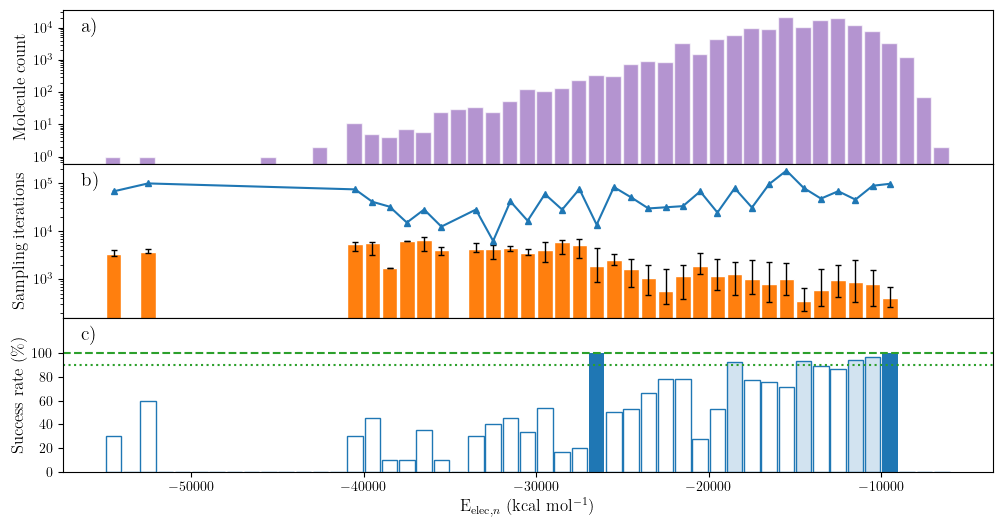

In [14]:
fs = 12
ticks_fs = 16
from matplotlib import gridspec
fig = plt.figure(figsize = (12,6))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1]) 

kcal_mol_const = 627.509474
#### loading target molecule ###
max_abs_err = 40
bin_size = 1000
bin_edges = np.arange(-55000, -5500, bin_size)

# ax = axs[0]
ax0 = plt.subplot(gs[0])
E_elec_n_ls = np.loadtxt("%sFIG7/E_elec_n_ls.txt"%(current_dir))
ax0.hist(E_elec_n_ls*kcal_mol_const, 
        width=bin_size*0.9, 
        bins=bin_edges, 
        edgecolor = "white",
        color=sns_palette[4], 
        alpha=0.7)
# ax.set_xlabel(r"$E_{elec}/N_{\rm atom}$ (kcal mol$^{-1}$)", fontsize=fs)
ax0.set_ylabel('Molecule count', fontsize=fs)
ax0.set_yscale('log')
ax0.set_yticks([1, 10, 100, 1000, 10000])
xmin, xmax = ax0.get_xlim()

ax1 = plt.subplot(gs[1])
x = np.loadtxt("%sFIG7/x.txt"%(current_dir))
bo_50_ls = np.loadtxt("%sFIG7/bo_50_ls.txt"%(current_dir))
bo_25_ls = np.loadtxt("%sFIG7/bo_25_ls.txt"%(current_dir))
bo_75_ls = np.loadtxt("%sFIG7/bo_75_ls.txt"%(current_dir))
rects = ax1.bar(x, bo_50_ls, 
                width=bin_size*0.9, 
                yerr = [bo_25_ls, bo_75_ls],
                color = sns_palette[1], 
                edgecolor = "white",
                capsize=2,
                error_kw=dict(elinewidth=1, capthick=1, ecolor='black'),
                #    alpha = 0.5, 
                zorder = -1)
qm9_E_medium_rand_itr_ls = np.loadtxt("%sFIG7/qm9_E_medium_rand_itr_ls.txt"%(current_dir))
ax1.plot(qm9_E_medium_rand_itr_ls[:, 0], 
         qm9_E_medium_rand_itr_ls[:, 1], 
         '^-', color=sns_palette[0], 
         markersize=5)
ax1.set_yscale('log')
ax1.set_ylabel('Sampling iterations', fontsize=fs)
ax1.set_xlim(xmin, xmax)
plt.setp(ax0.get_xticklabels(), visible=False)

ax2 = plt.subplot(gs[2])
success_50_ls = np.loadtxt("%sFIG7/success_50_ls.txt"%(current_dir))
rects = ax2.bar(x, [item[0] for item in success_50_ls], 
                width=bin_size*0.9, 
                color = sns_palette[0], 
                capsize=5,
                linewidth=1,
                zorder = -1)

# Fill or change color if y == 100
for rect, val in zip(rects, success_50_ls):
    if val[0] == 100:
        rect.set_facecolor(sns_palette[0])  # Set your fill color here
    elif val[0] > 90:
        rect.set_facecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.2))  # Set your fill color here
        rect.set_edgecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1))  # Set your edge color here
    else:
        rect.set_facecolor("white")  # Set your fill color here
        rect.set_edgecolor(sns_palette[0])  # Set your edge color here
plt.setp(ax0.get_xticklabels(), visible=False)
# # Loop through each label and set a white background box
# for label in labels:
#   label.set_bbox(dict(facecolor="white", edgecolor="none", pad=2))

ax2.set_xlim(xmin, xmax)

ax2.set_ylim(0, 130)
ax2.set_xlabel(r"${\rm E}_{{\rm elec}, n}$ (kcal mol$^{-1}$)", fontsize=fs)
ax2.set_ylabel('Success rate (\%)', fontsize=fs)
ax2.axhline(y=90, color=sns_palette[2], linestyle=':', label='90% Success Rate')  # Add a horizontal line at 80%
ax2.axhline(y=100, color=sns_palette[2], linestyle='--', label='100% Success Rate')  # Add a horizontal line at 100%
ax2.set_yticks(np.arange(0, 101, 20, dtype=int))

ax0.annotate(r"a)", (0.02, 0.95), xycoords='axes fraction', fontsize=fs+2, va='top', ha='left')
ax1.annotate(r"b)", (0.02, 0.95), xycoords='axes fraction', fontsize=fs+2, va='top', ha='left')
ax2.annotate(r"c)", (0.02, 0.95), xycoords='axes fraction', fontsize=fs+2, va='top', ha='left')

plt.subplots_adjust(hspace=.0)
fig.savefig("figure_7.pdf", bbox_inches='tight')

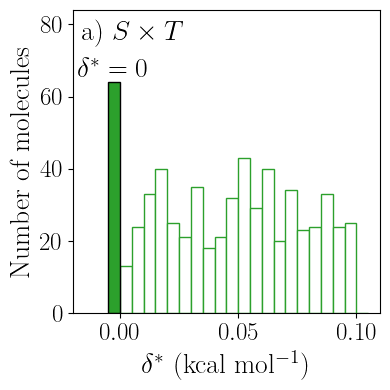

In [37]:
prop_n = "s"
fig8_s_dir = f"{current_dir}FIG8/{prop_n}/"
target_dict = np.load(f"{fig8_s_dir}target_dictionary_{prop_n}.npy", allow_pickle=True)[()]
smi_ls = target_dict["SMILES"]
result_summary_dict = np.load(f"{fig8_s_dir}MolMap_result_summary_dict.npy", allow_pickle=True)[()]
success_best_delta = []
success_best_delta = []
delta_zero_ls = []
delta_zero_dict = {}
for task_id, smi in enumerate(smi_ls):
    target_dsgdb9nsd = target_dict["dsgdb9nsd"][task_id]
    summary_dict_i = result_summary_dict[target_dsgdb9nsd]
    bo_status = summary_dict_i["bo_status"]
    best_delta =[-1 * summary_dict_i["best_target_val"][i] for i, status in enumerate(bo_status) if status == 1 and summary_dict_i["best_target_val"][i] != 0]
    delta_zero_ls.append([i for i, status in enumerate(bo_status) if status == 1 and summary_dict_i["best_target_val"][i] == 0])

    success_best_delta += best_delta

fig, ax = plt.subplots(1, 1, figsize = (4, 4), tight_layout = True)
fs = 20
bin_size = 0.005
bin_edges = np.arange(0, 0.11, bin_size)



ax.hist(success_best_delta, bins = bin_edges, color = "white",edgecolor = sns_palette[2])
ax.bar([-bin_size/2], [len(delta_zero_ls)], width=bin_size, color = sns_palette[2], edgecolor = "k")
ax.set_xlabel(r"$\delta^*$ (kcal mol$^{-1}$)", fontsize=fs)
ax.set_ylabel('Number of molecules', fontsize=fs)
ax.tick_params(axis='both',labelsize=fs-2)
# ax.set_ylim(0, 90)
ax.set_ylim(0, len(delta_zero_ls)+20)
ax.set_xlim(-0.02, 0.11)
ax.annotate(r"$\delta^* = 0$", (-bin_size/2, len(delta_zero_ls)), fontsize=fs, va='bottom', ha='center')
ax.annotate(r"a) $S\times T$", (0.03, 0.9), xycoords='axes fraction', fontsize=fs)
fig.savefig("figure_8_a.pdf", bbox_inches='tight')

len(delta_zero_ls): 129


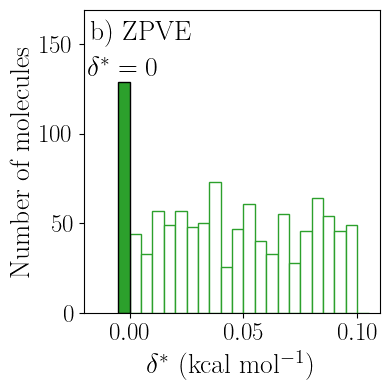

In [42]:
prop_n = "zpve"
fig8_zpve_dir = f"{current_dir}FIG8/{prop_n}/"

target_dict = np.load(f"{fig8_zpve_dir}target_dictionary_{prop_n}.npy", allow_pickle=True)[()]
np.save(f"{fig8_zpve_dir}target_dictionary_{prop_n}.npy", target_dict, allow_pickle=True)
smi_ls = target_dict["SMILES"]
result_summary_dict = np.load(f"{fig8_zpve_dir}MolMap_result_summary_dict.npy", allow_pickle=True)[()]
np.save(f"{fig8_zpve_dir}MolMap_result_summary_dict.npy", result_summary_dict, allow_pickle=True)
success_best_delta = []
delta_zero_ls = []
for task_id, smi in enumerate(smi_ls):
    target_dsgdb9nsd = target_dict["dsgdb9nsd"][task_id]
    summary_dict_i = result_summary_dict[target_dsgdb9nsd]
    bo_status = summary_dict_i["bo_status"]
    best_delta =[-1 * summary_dict_i["best_target_val"][i] for i, status in enumerate(bo_status) if status == 1 and summary_dict_i["best_target_val"][i] != 0]
    delta_zero_ls.append([i for i, status in enumerate(bo_status) if status == 1 and summary_dict_i["best_target_val"][i] == 0])
    success_best_delta += best_delta
fig, ax = plt.subplots(1, 1, figsize = (4,4), tight_layout = True)
fs = 20
bin_size = 0.005
bin_edges = np.arange(0, 0.11, bin_size)
ax.hist(success_best_delta, bins = bin_edges, color = "white",edgecolor = sns_palette[2])
ax.bar([-bin_size/2], [len(delta_zero_ls)], width=bin_size, color = sns_palette[2], edgecolor = "k")
ax.set_xlabel(r"$\delta^*$ (kcal mol$^{-1}$)", fontsize=fs)
ax.set_ylabel('Number of molecules', fontsize=fs)
ax.tick_params(axis='both',labelsize=fs-2)
ax.set_ylim(0, len(delta_zero_ls)+40)
ax.set_xlim(-0.02, 0.11)
ax.annotate(r"$\delta^* = 0$", (-bin_size/2, len(delta_zero_ls)), fontsize=fs, va='bottom', ha='center')
ax.annotate(r"b) ZPVE", (0.02, 0.9), xycoords='axes fraction', fontsize=fs)
print ("len(delta_zero_ls):", len(delta_zero_ls))
fig.savefig("figure_8_b.pdf", bbox_inches='tight')


len(delta_zero_ls): 134


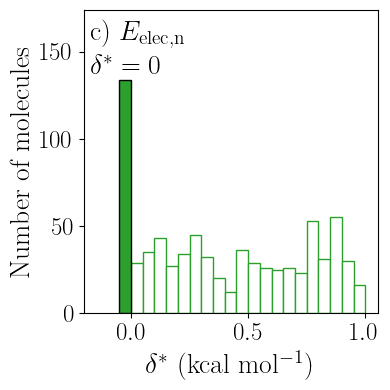

In [ ]:
prop_n = "E_elec_n"
fig8_E_elec_n_dir = f"{current_dir}FIG8/{prop_n}/"
target_dict = np.load(f"{fig8_E_elec_n_dir}target_dictionary_{prop_n}.npy", allow_pickle=True)[()]
np.save(f"{fig8_E_elec_n_dir}target_dictionary_{prop_n}.npy", target_dict, allow_pickle=True)
smi_ls = target_dict["SMILES"]
result_summary_dict = np.load(f"{fig8_E_elec_n_dir}MolMap_lhs_rand_result_summary_dict.npy", allow_pickle=True)[()]
np.save(f"{fig8_E_elec_n_dir}MolMap_lhs_rand_result_summary_dict.npy", result_summary_dict, allow_pickle=True)
success_best_delta = []
delta_zero_ls = []
for task_id, smi in enumerate(smi_ls):
    target_dsgdb9nsd = target_dict["dsgdb9nsd"][task_id]
    summary_dict_i = result_summary_dict[target_dsgdb9nsd]
    bo_status = summary_dict_i["bo_status"]
    best_delta =[-1 * summary_dict_i["best_target_val"][i] for i, status in enumerate(bo_status) if status == 1 and summary_dict_i["best_target_val"][i] != 0]
    delta_zero_ls.append([i for i, status in enumerate(bo_status) if status == 1 and summary_dict_i["best_target_val"][i] == 0])
    success_best_delta += best_delta
fig, ax = plt.subplots(1, 1, figsize = (4, 4), tight_layout = True)
fs = 20
bin_size = 0.05
bin_edges = np.arange(0, 1.05, bin_size)
ax.hist(success_best_delta, bins = bin_edges, color = "white",edgecolor = sns_palette[2])
ax.bar([-bin_size/2], [len(delta_zero_ls)], width=bin_size, color = sns_palette[2], edgecolor = "k")
ax.set_xlabel(r"$\delta^*$ (kcal mol$^{-1}$)", fontsize=fs)
ax.set_ylabel('Number of molecules', fontsize=fs)
ax.tick_params(axis='both',labelsize=fs-2)
ax.set_ylim(0, len(delta_zero_ls)+40)
ax.annotate(r"$\delta^* = 0$", (-0.02, len(delta_zero_ls)), fontsize=fs, va='bottom', ha='center')
ax.annotate(r"c) $E_{\rm elec,n}$", (0.02, 0.9), xycoords='axes fraction', fontsize=fs)
ax.set_xlim(-0.2, None)
print ("len(delta_zero_ls):", len(delta_zero_ls))
fig.savefig("figure_8_c.pdf", bbox_inches='tight')

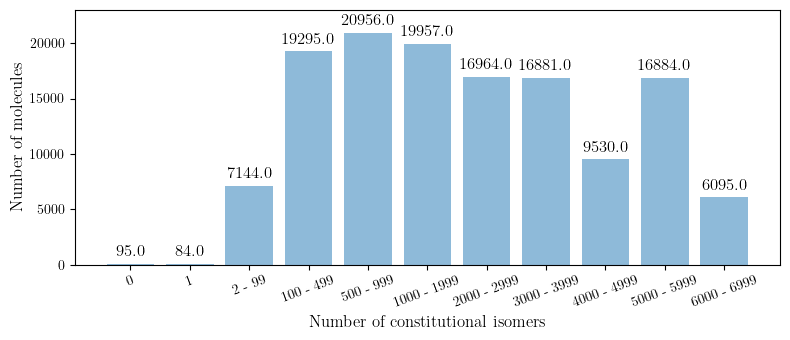

In [21]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
})

fig, ax = plt.subplots(figsize=(8, 3.5), tight_layout = True)
x = np.loadtxt(f"{current_dir}FIG9/x.txt")
y = np.loadtxt(f"{current_dir}FIG9/y.txt")
rects = ax.bar(x, y, alpha = 0.5)
ax.bar_label(rects,
              labels = [f"{y_i}" for y_i in y],
              label_type = 'edge',
              fontsize = 12,
              rotation = 0,
              color = "k",
              padding = 3,
              )
# 3. Replace the numerical X ticks with your text labels
ax.set_xticks(x)
x_labels = []
size_range_ls = [1, 2, 100, 500, 1000, 2000, 3000, 4000, 5000, 6000, 7000]

for i in range(len(size_range_ls)):
    if i in [0, 1]:
        x_labels.append(f"{size_range_ls[i]-1}")
    else:
        x_labels.append(f"{size_range_ls[i-1]} - {size_range_ls[i]-1}")
ax.set_xticklabels(x_labels, rotation=20, ha='center')
ax.set_xlabel(r'Number of constitutional isomers', fontsize=12)
ax.set_ylabel("Number of molecules", fontsize=12)
ax.set_ylim(0, 23000)
fig.savefig("figure_9.pdf", bbox_inches='tight')

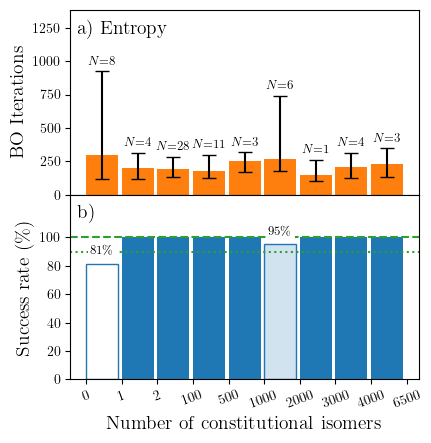

In [28]:
width = 0.9
fontsize = 14
prop_n = "s"

fig = plt.figure(figsize=(4.5,4.8))
gs = gridspec.GridSpec(2, 1) 

# fig, axs = plt.subplots(2, 1, figsize=(6, 4), tight_layout = True)
# ax = axs[0]
ax0 = plt.subplot(gs[0])

x = np.loadtxt("%sFIG10/%s/x.txt"%(current_dir, prop_n))
bo_50_ls = np.loadtxt("%sFIG10/%s/bo_50_ls.txt"%(current_dir, prop_n))
bo_25_ls = np.loadtxt("%sFIG10/%s/bo_25_ls.txt"%(current_dir, prop_n))
bo_75_ls = np.loadtxt("%sFIG10/%s/bo_75_ls.txt"%(current_dir, prop_n))
success_50_ls = np.loadtxt("%sFIG10/%s/success_50_ls.txt"%(current_dir, prop_n))
n_molecules = np.loadtxt("%sFIG10/%s/n_molecules.txt"%(current_dir, prop_n))
    
ax0.bar(x , 
       bo_50_ls, 
       width,
       yerr = [bo_25_ls, bo_75_ls],
       capsize=5,
       linewidth=1,
       color = sns_palette[1])
max_y = 0
for n in range(len(n_molecules)):
    y = bo_50_ls[n]+bo_75_ls[n]
    ax0.annotate(
        # r"$N_{\rm iso}$=%d"%(n_molecules[n]),
        r"$N$=%d"%(n_molecules[n]),
        # r"%d"%(n_molecules[n]),
                (x[n], y),
                textcoords="offset points",
                fontsize=fontsize-5,
                xytext=(0,5), ha='center')
    if y > max_y:
        max_y = y
ax0.set_ylim(0, max_y*1.5)
ax0.set_ylabel('BO Iterations', fontsize=fontsize)
# ax0.set_xlabel(r'Number of constitutional isomers', fontsize=fontsize)
ax0.set_xticks([])

# ax = axs[1]
ax1 = plt.subplot(gs[1])
rects = ax1.bar(x, 
               [item[0] for item in success_50_ls],
       width = width, 
       color = sns_palette[0])
labels = ax1.bar_label(rects, 
             padding=5, 
             fontsize=fontsize-5,
             color="k", 
             fmt=lambda x: f"" if x == 100 else f"{x:.0f}\%")

# Fill or change color if y == 100
for rect, val in zip(rects, success_50_ls):
    if val[0] == 100:
        rect.set_facecolor(sns_palette[0])  # Set your fill color here
    elif val[0] > 90:
        rect.set_facecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.2))  # Set your fill color here
        rect.set_edgecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1))  # Set your edge color here
    else:
        rect.set_facecolor("white")  # Set your fill color here
        rect.set_edgecolor(sns_palette[0])  # Set your edge color here

# Loop through each label and set a white background box
for label in labels:
  label.set_bbox(dict(facecolor="white", edgecolor="none", pad=2))

# for i, (rect, item) in enumerate(zip(rects, success_50_ls)):
#     ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 1, 
#             f'{item[1]}/{item[2]}', ha='center', va='bottom', fontsize=10)
ax1.set_ylabel('Success rate (\%)', fontsize=fontsize)
ax1.set_ylim(0, 130)  # Set y-axis limit for success rate to be between 0 and 100
# ax1.axhline(y=80, color=sns_palette[2], linestyle=':', label='80% Success Rate')  # Add a horizontal line at 80%
ax1.axhline(y=90, color=sns_palette[2], linestyle=':', label='90% Success Rate')  # Add a horizontal line at 80%
ax1.axhline(y=100, color=sns_palette[2], linestyle='--', label='100% Success Rate')  # Add a horizontal line at 100%
ax1.set_yticks(np.arange(0, 101, 20))

ax1.set_xticks(np.append(x, x[-1]+1)-width/2)
x_labels = np.loadtxt("%sFIG10/%s/x_labels.txt"%(current_dir, prop_n), dtype=str)
ax1.set_xticklabels(x_labels, 
                    rotation=20, 
                    ha='center')
ax1.set_xlabel(r'Number of constitutional isomers', fontsize=fontsize)

ax0.annotate(r"a) Entropy", (0.02, 0.95), xycoords='axes fraction', fontsize=fontsize, va='top', ha='left')
ax1.annotate(r"b)", (0.02, 0.95), xycoords='axes fraction', fontsize=fontsize, va='top', ha='left')


plt.setp(ax0.get_xticklabels(), visible=False)
plt.subplots_adjust(hspace=.0)

fig.savefig("figure_10_ab.pdf", bbox_inches='tight')


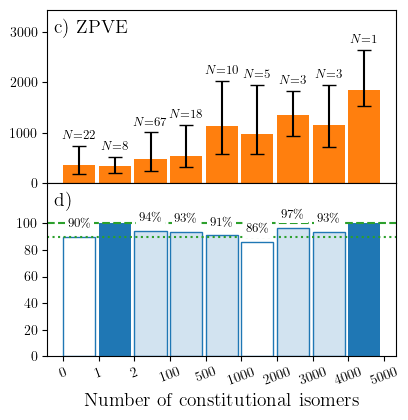

In [30]:
# 2. Shift X positions left and right
sns_palette = sns.color_palette()
fontsize = 14
# fig, axs = plt.subplots(2, 1, figsize=(4.5, 4.5), tight_layout=True)
# ax = axs[0]
fig = plt.figure(figsize=(4.5,4.5))
gs = gridspec.GridSpec(2, 1) 

# fig, axs = plt.subplots(2, 1, figsize=(6, 4), tight_layout = True)
# ax = axs[0]
ax0 = plt.subplot(gs[0])

x = np.loadtxt("%sFIG10/zpve/x.txt"%(current_dir))
bo_50_ls = np.loadtxt("%sFIG10/zpve/bo_50_ls.txt"%(current_dir))
bo_25_ls = np.loadtxt("%sFIG10/zpve/bo_25_ls.txt"%(current_dir))
bo_75_ls = np.loadtxt("%sFIG10/zpve/bo_75_ls.txt"%(current_dir))
success_50_ls = np.loadtxt("%sFIG10/zpve/success_50_ls.txt"%(current_dir))
n_molecules = np.loadtxt("%sFIG10/zpve/n_molecules.txt"%(current_dir))

ax0.bar(x , 
       bo_50_ls, 
       width,
       yerr = [bo_25_ls, bo_75_ls],
       capsize=5,
       linewidth=1,
       color = sns_palette[1])
max_y = 0
for n in range(len(n_molecules)):
    y = bo_50_ls[n]+bo_75_ls[n]
    ax0.annotate(
        # r"$N_{\rm iso}$=%d"%(n_molecules[n]),
        r"$N$=%d"%(n_molecules[n]),
                (x[n], y),
                fontsize=fontsize-5,
                textcoords="offset points",
                xytext=(0,5), ha='center')
    if y > max_y:
        max_y = y
ax0.set_ylim(0, max_y*1.3)
ax0.set_xticks([])

# ax = axs[1]
ax1 = plt.subplot(gs[1])
rects = ax1.bar(x, 
               success_50_ls,
       width = width, 
       color = sns_palette[0])
labels = ax1.bar_label(rects, 
             padding=5, 
             fontsize=fontsize-5,
             color="k", 
             fmt=lambda x: f"" if x == 100 else f"{x:.0f}\%")

# Fill or change color if y == 100
for rect, val in zip(rects, success_50_ls):
    if val == 100:
        rect.set_facecolor(sns_palette[0])  # Set your fill color here
    elif val >= 90:
        rect.set_facecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.2))  # Set your fill color here
        rect.set_edgecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1))  # Set your edge color here
    else:
        rect.set_facecolor("white")  # Set your fill color here
        rect.set_edgecolor(sns_palette[0])  # Set your edge color here

# Loop through each label and set a white background box
for label in labels:
  label.set_bbox(dict(facecolor="white", edgecolor="none", pad=2))

# ax.set_ylabel('Success rate (\%)', fontsize=fontsize)
# ax1.set_ylabel('Success rate (\%)', fontsize=fontsize)
ax1.set_ylim(0, 130)  # Set y-axis limit for success rate to be between 0 and 100
ax1.axhline(y=90, color = sns_palette[2], linestyle=':', label='80% Success Rate')  # Add a horizontal line at 80%
ax1.axhline(y=100, color = sns_palette[2], linestyle='--', label='100% Success Rate')  # Add a horizontal line at 100%
ax1.set_yticks(np.arange(0, 101, 20))
ax1.set_xticks(np.append(x, x[-1]+1)-width/2)
x_labels = np.loadtxt("%sFIG10/zpve/x_labels.txt"%(current_dir), dtype=str)
ax1.set_xticklabels(x_labels, 
                    rotation=20, 
                    ha='center')
ax1.set_xlabel(r'Number of constitutional isomers', fontsize=fontsize)

ax0.annotate(r"c) ZPVE", (0.02, 0.95), xycoords='axes fraction', fontsize=fontsize, va='top', ha='left')
ax1.annotate(r"d)", (0.02, 0.95), xycoords='axes fraction', fontsize=fontsize, va='top', ha='left')

plt.setp(ax0.get_xticklabels(), visible=False)
plt.subplots_adjust(hspace=.0)
fig.savefig("figure_10_cd.pdf", bbox_inches='tight')


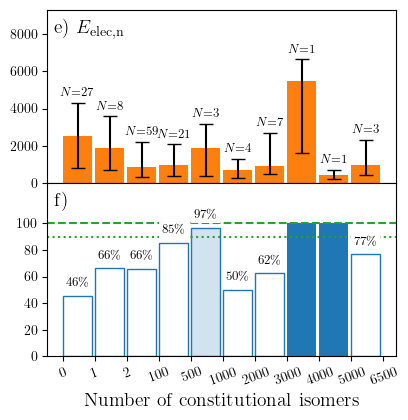

In [33]:
prop_n = "E_elec_n"
# 2. Shift X positions left and right
sns_palette = sns.color_palette()
fontsize = 14
# fig, axs = plt.subplots(2, 1, figsize=(4.5,4.5), tight_layout=True)
# ax = axs[0]
fig = plt.figure(figsize=(4.5,4.5))
gs = gridspec.GridSpec(2, 1) 
ax0 = plt.subplot(gs[0])

x = np.loadtxt("%sFIG10/%s/x.txt"%(current_dir, prop_n))
bo_50_ls = np.loadtxt("%sFIG10/%s/bo_50_ls.txt"%(current_dir, prop_n))
bo_25_ls = np.loadtxt("%sFIG10/%s/bo_25_ls.txt"%(current_dir, prop_n))
bo_75_ls = np.loadtxt("%sFIG10/%s/bo_75_ls.txt"%(current_dir, prop_n))
success_50_ls = np.loadtxt("%sFIG10/%s/success_50_ls.txt"%(current_dir, prop_n))
n_molecules = np.loadtxt("%sFIG10/%s/n_molecules.txt"%(current_dir, prop_n))

ax0.bar(x , 
       bo_50_ls, 
       width,
       yerr = [bo_25_ls, bo_75_ls],
       capsize=5,
       linewidth=1,
       color = sns_palette[1]
       )
max_y = 0
for n in range(len(n_molecules)):
    y = bo_50_ls[n]+bo_75_ls[n]
    ax0.annotate(
        # r"$N_{\rm iso}$=%d"%(n_molecules[n]),
        r"$N$=%d"%(n_molecules[n]),
                (x[n], y),
                textcoords="offset points",
                fontsize=fontsize-5,
                xytext=(0,5), 
                ha='center')
    if y > max_y:
        max_y = y
# ax.set_ylabel('Median BO Iterations', fontsize=fontsize)
# ax.set_xticks([])
ax0.set_ylim(0, max_y*1.4)
# ax.annotate(r"e) $E_{\rm elec,n}$", xy=(-0.6, 5200), fontsize=fontsize)
ax0.annotate(r"e) $E_{\rm elec,n}$", (0.02, 0.95), xycoords='axes fraction', fontsize=fontsize, va='top', ha='left')

# ax = axs[1]
ax1 = plt.subplot(gs[1])
rects = ax1.bar(x, 
               success_50_ls,
       width = width, 
       color = sns_palette[0])
# Fill or change color if y == 100
for rect, val in zip(rects, success_50_ls):
    if val == 100:
        rect.set_facecolor(sns_palette[0])  # Set your fill color here
    elif val > 90:
        rect.set_facecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.2))  # Set your fill color here
        rect.set_edgecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1))  # Set your edge color here
    else:
        rect.set_facecolor("white")  # Set your fill color here
        rect.set_edgecolor(sns_palette[0])  # Set your edge color here

labels = ax1.bar_label(rects, 
             padding=5, 
             color="k", 
             fontsize=fontsize-5,
             fmt=lambda x: f"" if x==100 else f"{x:.0f}\%")

# Loop through each label and set a white background box
for label in labels:
  label.set_bbox(dict(facecolor="white", edgecolor="none", pad=2))

ax1.axhline(y=90, color=sns_palette[2], linestyle=':', label='90% Success Rate')  # Add a horizontal line at 80%
ax1.axhline(y=100, color=sns_palette[2], linestyle='--', label='100% Success Rate')  # Add a horizontal line at 100%
ax1.set_yticks(np.arange(0, 101, 20))
# 3. Replace the numerical X ticks with your text labels
ax1.set_xticks(np.append(x, x[-1]+1)-width/2)
x_labels = np.loadtxt("%sFIG10/%s/x_labels.txt"%(current_dir, prop_n), dtype=str)
ax1.set_xticklabels(x_labels, 
                    rotation=20, 
                    ha='center')
ax1.set_xlabel(r'Number of constitutional isomers', fontsize=fontsize)
ax1.set_ylim(0, 130)
ax1.annotate("f)", (0.02, 0.95), xycoords='axes fraction', fontsize=fontsize, va='top', ha='left')

plt.setp(ax0.get_xticklabels(), visible=False)
plt.subplots_adjust(hspace=.0)
fig.savefig("figure_10_ef.pdf", bbox_inches='tight')

/var/folders/4g/_4b7gwg52572r3yvvt5619t80000gn/T/ipykernel_22873/343581433.py:55: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax0.set_ylim(0, 10**7)
/var/folders/4g/_4b7gwg52572r3yvvt5619t80000gn/T/ipykernel_22873/343581433.py:149: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0, 10**7)


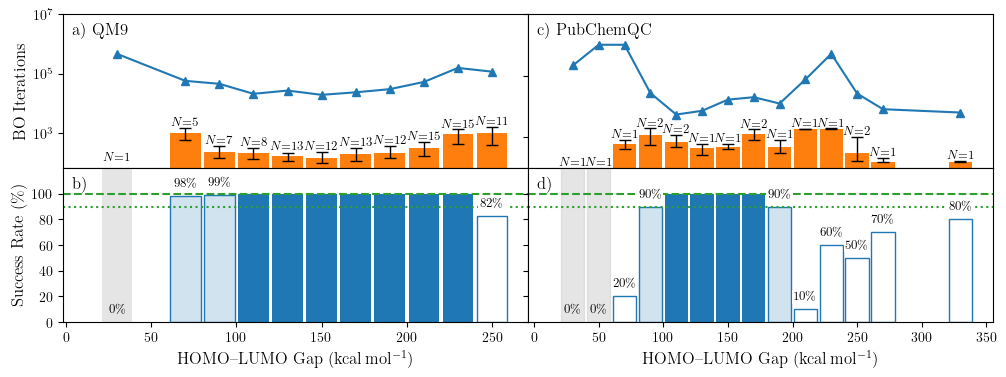

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # or "serif", "sans-serif", "monospace"
    'font.weight': 'bold',
    "font.serif": ["Times New Roman"] # Example for a specific font
    })
sns_pal= sns.color_palette("tab10")

bin_size = 20
fs = 12
fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(2, 2) 

# fig, axs = plt.subplots(2, 1, figsize=(6, 4), tight_layout = True)
# ax = axs[0]
ax0 = plt.subplot(gs[0,0])

# ax.bar(x_ls, medium_bo_itr_ls, width=0.9, color=sns_pal[0])
qm9_gap_x_ls = np.loadtxt("%sFIG11/qm9_gap_x_ls.txt"%(current_dir))
qm9_gap_medium_bo_itr_ls = np.loadtxt("%sFIG11/qm9_gap_medium_bo_itr_ls.txt"%(current_dir))
qm9_gap_bo_itr_25_ls = np.loadtxt("%sFIG11/qm9_gap_bo_itr_25_ls.txt"%(current_dir))
qm9_gap_bo_itr_75_ls = np.loadtxt("%sFIG11/qm9_gap_bo_itr_75_ls.txt"%(current_dir))
qm9_gap_success_rate_ls = np.loadtxt("%sFIG11/qm9_gap_success_rate_ls.txt"%(current_dir))
qm9_gap_n_molecules = np.loadtxt("%sFIG11/qm9_gap_n_molecules.txt"%(current_dir))
qm9_gap_medium_rand_itr_ls = np.loadtxt("%sFIG11/qm9_gap_medium_rand_itr_ls.txt"%(current_dir))
rects = ax0.bar(qm9_gap_x_ls, qm9_gap_medium_bo_itr_ls,
                width=bin_size-2,
                yerr=[np.array(qm9_gap_medium_bo_itr_ls)-np.array(qm9_gap_bo_itr_25_ls),
                      np.array(qm9_gap_bo_itr_75_ls)-np.array(qm9_gap_medium_bo_itr_ls)],
                color = sns_pal[1],
                capsize=bin_size*0.2,
                error_kw=dict(elinewidth=1, capthick=1, ecolor='black'),
                zorder = -1)
ax0.set_ylabel('BO Iterations', fontsize=fs)
# ax.set_xticks(prop_val_ls)
# ax.set_xlim(0, None)
ax0.annotate("a) QM9", (0.02, 0.95), xycoords='axes fraction', fontsize=fs, va='top', ha='left')

for idx, x_i in enumerate(qm9_gap_x_ls):
    if int(qm9_gap_bo_itr_75_ls[idx]) > 0:
        ax0.annotate(f"$N$={int(qm9_gap_n_molecules[idx])}", 
                    (x_i, qm9_gap_bo_itr_75_ls[idx]+10), 
                    fontsize=fs-3, ha='center', va='bottom')
    else:
        ax0.annotate(f"$N$={int(qm9_gap_n_molecules[idx])}", 
                         (x_i, 100), 
                         fontsize=fs-3, ha='center', va='bottom')
# ax0.set_ylim(0, 2300)
ax0.plot(qm9_gap_medium_rand_itr_ls[:,0], qm9_gap_medium_rand_itr_ls[:,1], "^-",)
ax0.set_yscale('log') 
ax0.set_xlim(-2, None)
ax0.set_ylim(0, 10**7)
# ax0.tick_params(axis='y', which='minor', length=5, width=1)

# ax.set_xlabel('Alpha Gap', fontsize=fs) 
# ax = axs[1]
ax1 = plt.subplot(gs[1,0])
rects = ax1.bar(qm9_gap_x_ls, np.array(qm9_gap_success_rate_ls), width=bin_size-2, color=sns_pal[0])
def is_positive_integer(val):
    if val == 100:
        return 1
    return 0

labels = ax1.bar_label(rects, 
             padding=5, 
             fontsize=fs-3,
             color="k", 
             fmt=lambda x: "" if is_positive_integer(x) == 1 else f"{x:.0f}\%")


# ax0.set_ylim(0, 2700)

# Fill or change color if y == 100
idx = 0
for rect, val in zip(rects,  np.array(qm9_gap_success_rate_ls)):
    if val == 100:
        rect.set_facecolor(sns_pal[0])  # Set your fill color here
        idx += 1
    elif val > 90:
        rect.set_facecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.2))  # Set your fill color here
        rect.set_edgecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1))  # Set your edge color here
        idx += 1
    elif val == 0:
        bin_min = qm9_gap_x_ls[idx] - 0.5*bin_size
        bin_max = qm9_gap_x_ls[idx] + 0.5*bin_size
        ax1.fill_between([bin_min+1, bin_max-1], 0, 140, 
                         color = (0.8, 0.8, 0.8, 0.5), 
                         edgecolor = None, 
                         zorder = -1)
        idx += 1
    else:
        rect.set_facecolor("white")  # Set your fill color here
        rect.set_edgecolor(sns_pal[0])  # Set your edge color here
        idx += 1
# Loop through each label and set a white background box
for label in labels:
    if label.get_text() != f"0\%":
        label.set_bbox(dict(facecolor="white", edgecolor="none", pad=2))

ax1.set_ylabel('Success Rate (\%)', fontsize=fs)
ax1.set_xlabel(r'HOMO--LUMO Gap (${\rm kcal\,mol^{-1}}$)', fontsize=fs)
ax1.axhline(y=90, color=sns_pal[2], linestyle=':', label='90% Success Rate')  # Add a horizontal line at 90%
# ax.annotate("80\%", (0.08, 0.58), xycoords='axes fraction', fontsize=fs, va='top', ha='left')
ax1.axhline(y=100, color=sns_pal[2], linestyle='--', label='100% Success Rate')  # Add a horizontal line at 100%
# ax.annotate("100\%", (0.08, 0.92), xycoords='axes fraction', fontsize=fs, va='top', ha='left')
ax1.set_yticks(np.arange(0, 101, 20))
ax1.set_ylim(0, 120)
ax1.set_xlim(-2, None)

ax1.annotate("b)", (0.02, 0.95), xycoords='axes fraction', fontsize=fs, va='top', ha='left')

############################## PubChemQC results ##############################
ax2 = plt.subplot(gs[0,1])
pubchem_gap_x_ls = np.loadtxt("%sFIG11/pubchem_gap_x_ls.txt"%(current_dir))
pubchem_gap_medium_bo_itr_ls = np.loadtxt("%sFIG11/pubchem_gap_medium_bo_itr_ls.txt"%(current_dir))
pubchem_gap_bo_itr_25_ls = np.loadtxt("%sFIG11/pubchem_gap_bo_itr_25_ls.txt"%(current_dir))
pubchem_gap_bo_itr_75_ls = np.loadtxt("%sFIG11/pubchem_gap_bo_itr_75_ls.txt"%(current_dir))
pubchem_gap_success_rate_ls = np.loadtxt("%sFIG11/pubchem_gap_success_rate_ls.txt"%(current_dir))
pubchem_gap_n_molecules = np.loadtxt("%sFIG11/pubchem_gap_n_molecules.txt"%(current_dir))
pubchem_gap_medium_rand_itr_ls = np.loadtxt("%sFIG11/pubchem_gap_medium_rand_itr_ls.txt"%(current_dir))
rects = ax2.bar(pubchem_gap_x_ls, pubchem_gap_medium_bo_itr_ls,
                width=bin_size-2,
                yerr=[np.array(pubchem_gap_medium_bo_itr_ls)-np.array(pubchem_gap_bo_itr_25_ls), 
                      np.array(pubchem_gap_bo_itr_75_ls)-np.array(pubchem_gap_medium_bo_itr_ls)],
                color = sns_pal[1],
                capsize=bin_size*0.2,
                error_kw=dict(elinewidth=1, capthick=1, ecolor='black'),
                zorder = -1)
ax2.annotate("c) PubChemQC", (0.02, 0.95), xycoords='axes fraction', fontsize=fs, va='top', ha='left')


for idx, x_i in enumerate(pubchem_gap_x_ls):
    if pubchem_gap_bo_itr_75_ls[idx] > 0:
        ax2.annotate(f"$N$={int(pubchem_gap_n_molecules[idx])}", 
                    (x_i, pubchem_gap_bo_itr_75_ls[idx]+10), 
                    fontsize=fs-3, ha='center', va='bottom')
    else:
        ax2.annotate(f"$N$={int(pubchem_gap_n_molecules[idx])}", 
                        (x_i, 100), 
                        fontsize=fs-3, ha='center', va='bottom')

ax2.plot(pubchem_gap_medium_rand_itr_ls[:,0], pubchem_gap_medium_rand_itr_ls[:,1], "^-",)
ax2.set_yscale('log')
# ax2.set_ylim(0, 2700)
max_y = pubchem_gap_medium_rand_itr_ls[:,1].max() 
ax2.set_ylim(0, 10**7)
ax2.set_xlim(-5, None)

# ax.set_xlabel('Alpha Gap', fontsize=fs) 
# ax = axs[1]
ax3 = plt.subplot(gs[1,1])
rects = ax3.bar(pubchem_gap_x_ls, np.array(pubchem_gap_success_rate_ls), width=bin_size-2, color=sns_pal[0])

# Fill or change color if y == 100
idx = 0
for rect, val in zip(rects, np.array(pubchem_gap_success_rate_ls)):
    if val == 100:
        rect.set_facecolor(sns_pal[0])  # Set your fill color here
        idx += 1
    elif val >= 90:
        rect.set_facecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 0.2))  # Set your fill color here
        rect.set_edgecolor((0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1))  # Set your edge color here
        idx += 1
    elif val == 0:
        bin_min = pubchem_gap_x_ls[idx] - 0.5*bin_size
        bin_max = pubchem_gap_x_ls[idx] + 0.5*bin_size
        ax3.fill_between([bin_min+1, bin_max-1], 0, 140, color = (0.8, 0.8, 0.8, 0.5), zorder = -1)
        idx += 1
    else:
        rect.set_facecolor("white")  # Set your fill color here
        rect.set_edgecolor(sns_pal[0])  # Set your edge color here
        idx += 1
def is_positive_integer(val):
    if val == 100:
        return 1
    return 0

labels = ax3.bar_label(rects, 
             padding=5, 
             fontsize=fs-3,
             color="k", 
             fmt=lambda x: "" if is_positive_integer(x) == 1 else f"{x:.0f}\%")
# Loop through each label and set a white background box
for label in labels:
    if label.get_text() != f"0\%":
        label.set_bbox(dict(facecolor="white", edgecolor="none", pad=1))



# ax1.set_ylabel("Success Rate (\%)", fontsize=fs)
ax3.set_xlabel(r'HOMO--LUMO Gap (${\rm kcal\,mol^{-1}}$)', fontsize=fs)
ax3.axhline(y=90, color=sns_pal[2], linestyle=':', label='90% Success Rate')  # Add a horizontal line at 80%
# ax.annotate("80\%", (0.08, 0.58), xycoords='axes fraction', fontsize=fs, va='top', ha='left')
ax3.axhline(y=100, color=sns_pal[2], linestyle='--', label='100% Success Rate')  # Add a horizontal line at 100%
# ax.annotate("100\%", (0.08, 0.92), xycoords='axes fraction', fontsize=fs, va='top', ha='left')
ax3.set_yticks(np.arange(0, 101, 20))
ax3.set_ylim(0, 120)
ax3.set_xlim(-5, None)
ax3.annotate("d)", (0.02, 0.95), xycoords='axes fraction', fontsize=fs, va='top', ha='left')
plt.setp(ax0.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.subplots_adjust(hspace=.0, wspace=.0)
fig.savefig("figure11.pdf")
